# Project ASD - Session Data Analysis
Analyze therapy session data to improve outcomes

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [4]:
# Load session data
df = pd.read_csv('../data/sessions.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Parse details JSON
df['details_parsed'] = df['details'].apply(lambda x: json.loads(x) if pd.notna(x) else {})

print(f"Total events: {len(df)}")
print(f"Unique sessions: {df['session_id'].nunique()}")
df.head()

Total events: 0
Unique sessions: 0


,timestamp,session_id,event_type,engagement,music_style,note,details,details_parsed


## 1. Acceptance Rate Analysis

TypeError: no numeric data to plot

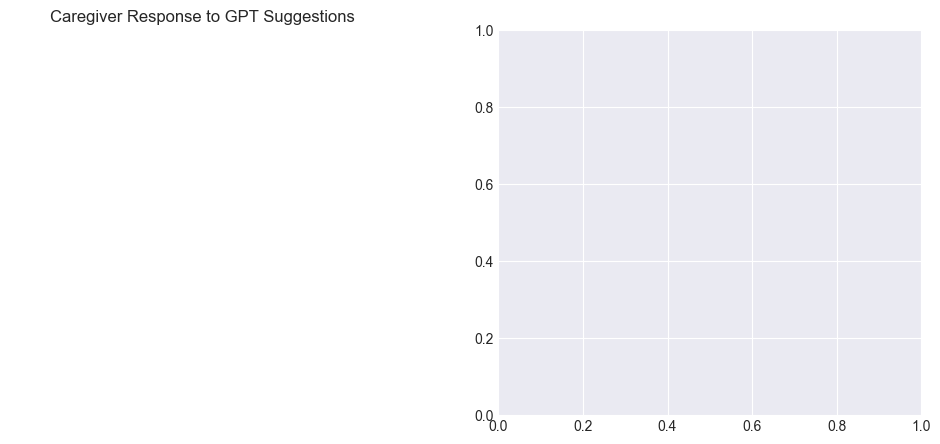

In [5]:
# Filter caregiver actions
actions = df[df['event_type'] == 'caregiver_action'].copy()
actions['action'] = actions['details_parsed'].apply(lambda x: x.get('action', ''))

# Calculate acceptance rates
acceptance_rate = actions['action'].value_counts(normalize=True)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
ax1.pie(acceptance_rate.values, labels=acceptance_rate.index, autopct='%1.1f%%')
ax1.set_title('Caregiver Response to GPT Suggestions')

# Bar chart by engagement
actions_by_engagement = actions.groupby(['engagement', 'action']).size().unstack(fill_value=0)
actions_by_engagement.plot(kind='bar', ax=ax2)
ax2.set_title('Actions by Engagement Level')
ax2.set_xlabel('Engagement Level')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Music Style Effectiveness

In [6]:
# Analyze music styles
music_events = df[df['music_style'].notna()].copy()

# Music style distribution
style_dist = music_events.groupby(['engagement', 'music_style']).size().unstack(fill_value=0)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(style_dist, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Music Style Selection by Engagement Level')
plt.xlabel('Music Style')
plt.ylabel('Engagement Level')
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x600 with 0 Axes>

## 3. Engagement Transitions

In [ ]:
# Track engagement transitions
engagement_changes = df[df['event_type'] == 'engagement_update'].copy()
engagement_changes['prev_engagement'] = engagement_changes.groupby('session_id')['engagement'].shift(1)
engagement_changes = engagement_changes.dropna(subset=['prev_engagement'])

# Create transition matrix
transitions = pd.crosstab(
    engagement_changes['prev_engagement'],
    engagement_changes['engagement'],
    normalize='index'
)

# Visualize transitions
plt.figure(figsize=(8, 6))
sns.heatmap(transitions, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Engagement Level Transition Probabilities')
plt.xlabel('To Engagement')
plt.ylabel('From Engagement')
plt.show()

## 4. Session Patterns

In [ ]:
# Analyze session patterns
sessions = df.groupby('session_id').agg({
    'timestamp': ['min', 'max'],
    'event_type': 'count'
}).reset_index()

sessions.columns = ['session_id', 'start_time', 'end_time', 'event_count']
sessions['duration_minutes'] = (sessions['end_time'] - sessions['start_time']).dt.total_seconds() / 60

# Plot session metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Duration distribution
axes[0, 0].hist(sessions['duration_minutes'], bins=20, edgecolor='black')
axes[0, 0].set_title('Session Duration Distribution')
axes[0, 0].set_xlabel('Duration (minutes)')
axes[0, 0].set_ylabel('Count')

# Events per session
axes[0, 1].hist(sessions['event_count'], bins=20, edgecolor='black')
axes[0, 1].set_title('Events per Session')
axes[0, 1].set_xlabel('Number of Events')
axes[0, 1].set_ylabel('Count')

# Time of day analysis
df['hour'] = df['timestamp'].dt.hour
hourly_activity = df.groupby('hour').size()
axes[1, 0].bar(hourly_activity.index, hourly_activity.values)
axes[1, 0].set_title('Activity by Hour of Day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Event Count')

# Suggestion frequency
suggestions = df[df['event_type'] == 'gpt_suggestion']
suggestions_per_session = suggestions.groupby('session_id').size()
axes[1, 1].hist(suggestions_per_session, bins=15, edgecolor='black')
axes[1, 1].set_title('GPT Suggestions per Session')
axes[1, 1].set_xlabel('Number of Suggestions')
axes[1, 1].set_ylabel('Session Count')

plt.tight_layout()
plt.show()

## 5. Key Metrics Summary

In [ ]:
# Calculate key metrics
total_sessions = df['session_id'].nunique()
avg_duration = sessions['duration_minutes'].mean()
acceptance_rate_overall = (actions['action'] == 'accept').mean() * 100

# Most effective music style by engagement
best_styles = {}
for engagement in ['LOW', 'MED', 'HIGH']:
    eng_actions = actions[actions['engagement'] == engagement]
    if len(eng_actions) > 0:
        accepted = eng_actions[eng_actions['action'] == 'accept']
        if len(accepted) > 0:
            # Get music style from previous GPT suggestion
            best_styles[engagement] = 'N/A'  # Placeholder

print("📊 Project ASD ANALYTICS SUMMARY")
print("=" * 40)
print(f"Total Sessions: {total_sessions}")
print(f"Average Session Duration: {avg_duration:.1f} minutes")
print(f"Overall Acceptance Rate: {acceptance_rate_overall:.1f}%")
print(f"Total GPT Suggestions: {len(suggestions)}")
print(f"\nMost Common Music Styles by Engagement:")
for level in ['LOW', 'MED', 'HIGH']:
    level_music = music_events[music_events['engagement'] == level]['music_style']
    if len(level_music) > 0:
        most_common = level_music.mode()[0] if len(level_music.mode()) > 0 else 'N/A'
        print(f"  {level}: {most_common}")